# *DOWNLOAD DEPENDENCIES

In [1]:
!pip install -q -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611

# *IMPORT DEPENDENCIES

In [2]:
import pandas as pd
import random
import os
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
# from sklearn.feature_extraction.text import TfidfVectorizer
from model_utils import (preprocess_text,
                         MultiClassSVM,
                         TfidfVectorizer,
                         ChiSquareSelector)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"SEED = {seed}")

SEED = 42
set_seed(SEED)

# Set plotting style
plt.style.use('seaborn-v0_8-muted')
sns.set_theme(style="whitegrid")


SEED = 42


# I. LOAD DATA

Total samples: 2092
Training set: 1464
Testing set: 628


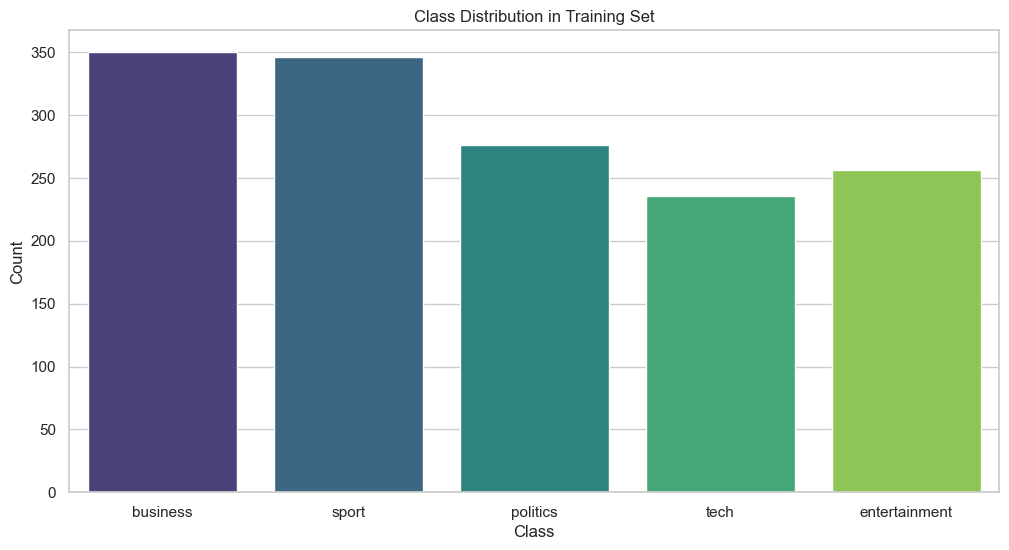

In [3]:
df = pd.read_csv('data.csv')

X = df['text'].to_numpy()
y = df['label'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=SEED,
    stratify=y
    )

print(f"Total samples: {len(df)}")
print(f"Training set: {len(X_train)}")
print(f"Testing set: {len(X_test)}")

plt.figure(figsize=(12, 6))
sns.countplot(
    x=y_train,
    hue=y_train,
    palette='viridis',
    legend=False
)
plt.title("Class Distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


# II. VECTORIZING


In [4]:
vectorizer = TfidfVectorizer(
    tokenizer=preprocess_text,
    preprocessor=None,
    token_pattern=None,

    lowercase=False,

    ngram_range=(1, 2),

    min_df=2,
    max_df=0.85,
    max_features=30000,

    binary=False,

    smooth_idf=True,
    norm="l2",
    
    sublinear_tf=True,
)


X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [5]:
len(vectorizer.vocabulary_)

30000

In [6]:
model = MultiClassSVM(
    C=0.01,
    kernel="linear",
)

model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     business       0.96      0.97      0.97       150
entertainment       0.98      0.96      0.97       110
     politics       0.95      0.97      0.96       119
        sport       0.99      0.99      0.99       148
         tech       0.97      0.94      0.95       101

     accuracy                           0.97       628
    macro avg       0.97      0.97      0.97       628
 weighted avg       0.97      0.97      0.97       628



# III. SELECTING CHI-SQUARE TOP K

In [7]:
for i in [100, 1000, 5000, 10000, 15000, 20000]:


  selector = ChiSquareSelector(
      k=i
  )

  X_train_chi = selector.fit_transform(
      X_train_tfidf,
      y_train
  )

  X_test_chi = selector.transform(
      X_test_tfidf
  )

  model = MultiClassSVM(
      C=0.01,
      kernel="linear",
  )

  model.fit(X_train_chi, y_train)
  y_pred = model.predict(X_test_chi)
  print(f"With Chi-square top k is {i}")
  print(classification_report(y_test, y_pred))

del selector
del X_train_chi
del X_test_chi
del model
del y_pred

With Chi-square top k is 100
               precision    recall  f1-score   support

     business       0.90      0.93      0.92       150
entertainment       0.95      0.85      0.89       110
     politics       0.92      0.93      0.93       119
        sport       0.92      0.97      0.94       148
         tech       0.91      0.87      0.89       101

     accuracy                           0.92       628
    macro avg       0.92      0.91      0.91       628
 weighted avg       0.92      0.92      0.92       628

With Chi-square top k is 1000
               precision    recall  f1-score   support

     business       0.95      0.97      0.96       150
entertainment       0.99      0.94      0.96       110
     politics       0.95      0.96      0.95       119
        sport       0.96      0.99      0.98       148
         tech       0.96      0.93      0.94       101

     accuracy                           0.96       628
    macro avg       0.96      0.96      0.96       628
 

# IV. INIT SELECTOR AND FIT TRANSFORM

In [8]:
selector = ChiSquareSelector(
    k=10000
)

X_train_chi = selector.fit_transform(
    X_train_tfidf,
    y_train
)

X_test_chi = selector.transform(
    X_test_tfidf
)

In [9]:
feature_names = vectorizer.get_feature_names_out()

selected_set = set(
    selector.selected_features_
)

mean_tfidf = np.asarray(
    X_train_tfidf.mean(axis=0)
).ravel()

df = pd.DataFrame({
    "term": feature_names,
    "tfidf": mean_tfidf,
    "chi": selector.scores_,
    "status": [
        "selected" if i in selected_set
        else "removed"
        for i in range(len(feature_names))
    ]
})

df = df.sort_values(
    "chi",
    ascending=False
)

df.to_csv(
    "chi2_result.csv",
    index=False,
    encoding="utf-8-sig"
)

# V. GRID SEARCH

In [10]:

param_grid = [
    {
        "kernel": ["linear"],
        "C": [0.01, 0.1, 1, 10],
    },

    {
        "kernel": ["rbf"],
        "C": [0.01, 0.1, 1, 10],
        "gamma": ["scale", "auto", 0.001, 0.01, 0.1],
    },

    {
        "kernel": ["poly"],
        "C": [0.01, 0.1, 1, 10],
        "gamma": ["scale", "auto", 0.001, 0.01, 0.1],
        "degree": [2, 3],
    },

    {
        "kernel": ["sigmoid"],
        "C": [0.01, 0.1, 1, 10],
        "gamma": ["scale", "auto", 0.001, 0.01, 0.1],
    }
]

print("Starting GridSearchCV...")

grid_search = GridSearchCV(
    estimator=MultiClassSVM(),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    verbose=3,
    n_jobs=1,
)

grid_search.fit(X_train_chi, y_train)
print("\nBest Score:", grid_search.best_score_)
print("Best Parameters:", grid_search.best_params_)

Starting GridSearchCV...
Fitting 3 folds for each of 84 candidates, totalling 252 fits
[CV 1/3] END .............C=0.01, kernel=linear;, score=0.971 total time=   3.3s
[CV 2/3] END .............C=0.01, kernel=linear;, score=0.962 total time=   3.2s
[CV 3/3] END .............C=0.01, kernel=linear;, score=0.951 total time=   3.3s
[CV 1/3] END ..............C=0.1, kernel=linear;, score=0.971 total time=   3.0s
[CV 2/3] END ..............C=0.1, kernel=linear;, score=0.962 total time=   3.1s
[CV 3/3] END ..............C=0.1, kernel=linear;, score=0.951 total time=   3.1s
[CV 1/3] END ................C=1, kernel=linear;, score=0.985 total time=   2.7s
[CV 2/3] END ................C=1, kernel=linear;, score=0.977 total time=   2.8s
[CV 3/3] END ................C=1, kernel=linear;, score=0.977 total time=   2.8s
[CV 1/3] END ...............C=10, kernel=linear;, score=0.984 total time=   3.1s
[CV 2/3] END ...............C=10, kernel=linear;, score=0.982 total time=   3.2s
[CV 3/3] END .........

# VI. TRAIN WITH BEST PARAMETERS


In [31]:
bp = grid_search.best_params_

best_svm = MultiClassSVM(**bp)
print("Training final model...")
print("Best parameters:", bp)

best_svm.fit(X_train_chi, y_train)

print("Training complete.")

Training final model...
Best parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Training complete.


# VII. EVALUATION


CLASSIFICATION REPORT:
               precision    recall  f1-score   support

     business       0.97      0.98      0.98       150
entertainment       0.98      0.98      0.98       110
     politics       0.96      0.97      0.97       119
        sport       0.99      0.99      0.99       148
         tech       0.98      0.95      0.96       101

     accuracy                           0.98       628
    macro avg       0.98      0.98      0.98       628
 weighted avg       0.98      0.98      0.98       628



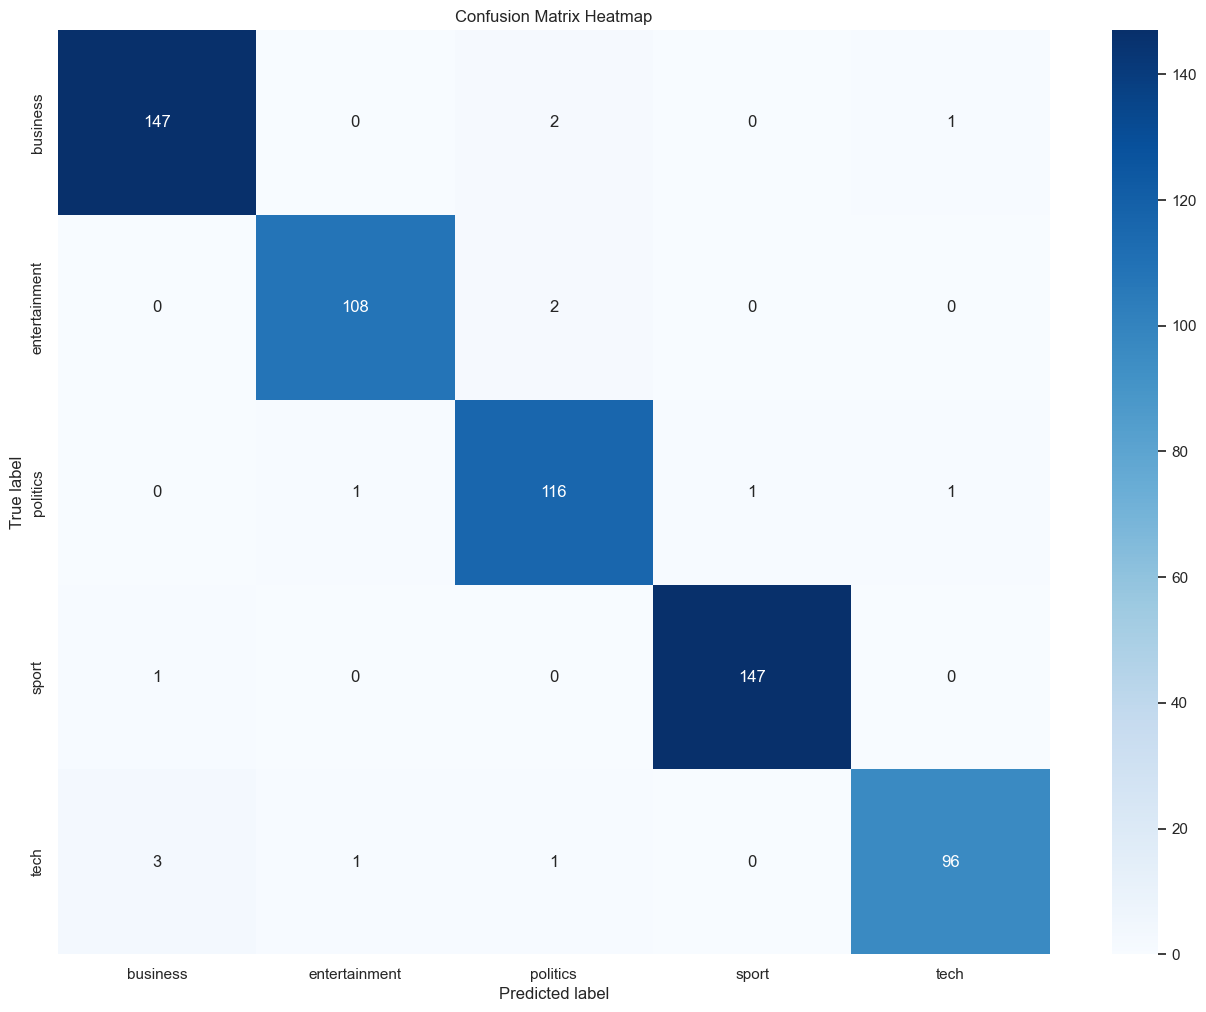

In [32]:
y_pred = best_svm.predict(X_test_chi)

# 1. Classification Report
print("CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, zero_division=0))

from sklearn.metrics import ConfusionMatrixDisplay

# 2. Confusion Matrix
labels = sorted(set(y_test) | set(y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(16, 12))

ax = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

ax.grid(False)
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# VIII. TOP 20 TERM CHI2 SCORE

In [33]:
feature_names = vectorizer.get_feature_names_out()

top_idx = np.argsort(selector.scores_)[::-1]

for rank, idx in enumerate(top_idx[:20], start=1):
    print(
        f"{rank:2d}. "
        f"{feature_names[idx]:20s} "
        f"{selector.scores_[idx]:.4f}"
    )

 1. government           632.7416
 2. user                 616.2867
 3. minister             610.2623
 4. technology           608.6529
 5. election             599.1903
 6. party                594.1668
 7. film                 562.2062
 8. computer             544.2224
 9. tory                 535.6090
10. secretary            519.2325
11. star                 514.2685
12. firm                 482.2335
13. company              479.4688
14. game                 477.4292
15. market               473.8421
16. NUM MONEY            470.4487
17. player               468.0139
18. general election     461.2702
19. coach                457.9899
20. online               445.7525


# IX. TOP SAMPLES

In [34]:
import numpy as np
from sklearn.utils import check_random_state

rng = check_random_state(SEED)

y_pred = best_svm.predict(X_test_chi)
scores = best_svm.decision_function(X_test_chi)

feature_names = vectorizer.get_feature_names_out()

selected_idx = selector.selected_features_
selected_feature_names = np.array(feature_names)[selected_idx]
selected_chi2 = selector.scores_[selected_idx]

chi2_map = dict(
    zip(
        selected_feature_names,
        selected_chi2
    )
)

correct_idx = np.flatnonzero(y_pred == y_test)
wrong_idx = np.flatnonzero(y_pred != y_test)


def show_sample(idx):

    pred = y_pred[idx]
    true = y_test[idx]

    print("=" * 120)
    print(f"Sample #{idx}")
    print(f"True : {true}")
    print(f"Pred : {pred}")

    sample_scores = scores[idx]

    ranked = sorted(
        zip(
            best_svm.classes_,
            sample_scores
        ),
        key=lambda x: x[1],
        reverse=True
    )

    margin = (
        ranked[0][1] - ranked[1][1]
        if len(ranked) > 1
        else np.nan
    )

    print(f"Margin: {margin:.6f}")

    print("\nCLASS SCORES")
    print("-" * 120)

    for cls, score in ranked:
        marker = ""

        if cls == pred:
            marker += " [PRED]"

        if cls == true:
            marker += " [TRUE]"

        print(
            f"{str(cls):<20}"
            f"{score:>12.6f}"
            f"{marker}"
        )

    print("\nTEXT")
    print("-" * 120)
    print(X_test[idx])

    row = X_test_chi[idx]

    top_features = sorted(
        (
            (
                selected_feature_names[c],
                float(row[0, c]),
                chi2_map[
                    selected_feature_names[c]
                ]
            )
            for c in row.nonzero()[1]
        ),
        key=lambda x: x[1],
        reverse=True
    )[:30]

    print("\nTOP FEATURES")
    print("-" * 120)

    print(
        f"{'TERM':<35}"
        f"{'TFIDF':>12}"
        f"{'CHI2':>15}"
    )

    for term, tfidf, chi2_score in top_features:

        print(
            f"{term:<35}"
            f"{tfidf:>12.6f}"
            f"{chi2_score:>15.2f}"
        )

    print()



for title, indices in [
    ("CORRECT", correct_idx),
    ("WRONG", wrong_idx),
]:

    print("\n" + "#" * 120)
    print(title)
    print("#" * 120)

    if len(indices) == 0:
        continue

    for idx in rng.choice(
        indices,
        size=min(5, len(indices)),
        replace=False,
    ):
        show_sample(idx)


########################################################################################################################
CORRECT
########################################################################################################################
Sample #356
True : politics
Pred : politics
Margin: 2.311850

CLASS SCORES
------------------------------------------------------------------------------------------------------------------------
politics                1.291084 [PRED] [TRUE]
sport                  -1.020765
tech                   -1.074885
entertainment          -1.273190
business               -1.586392

TEXT
------------------------------------------------------------------------------------------------------------------------
Row over 'police' power for CSOs.  The Police Federation has said it strongly opposes giving Community Support Officers (CSOs) the power to detain suspects for up to 30 minutes.  The powers - piloted in six areas - were extended to all police forc

In [35]:
grid_df = pd.DataFrame(grid_search.cv_results_)

In [36]:
display(grid_df.sort_values(by="mean_test_score", ascending=False).head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_kernel,param_gamma,param_degree,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
23,3.758249,0.062154,0.405886,0.008888,10.0,rbf,0.1,NaN,"{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}",0.985798,0.982710,0.980893,0.983134,0.002025,1
79,4.011826,0.060738,0.171220,0.009132,10.0,sigmoid,scale,NaN,"{'C': 10, 'gamma': 'scale', 'kernel': 'sigmoid'}",0.982101,0.986570,0.978788,0.982486,0.003189,2
74,3.465410,0.081435,0.159202,0.002142,1.0,sigmoid,scale,NaN,"{'C': 1, 'gamma': 'scale', 'kernel': 'sigmoid'}",0.985495,0.981358,0.978673,0.981842,0.002806,3
3,3.122177,0.075131,0.045664,0.002603,10.0,linear,NaN,NaN,"{'C': 10, 'kernel': 'linear'}",0.984174,0.981849,0.978788,0.981604,0.002206,4
2,2.823482,0.062728,0.049086,0.002167,1.0,linear,NaN,NaN,"{'C': 1, 'kernel': 'linear'}",0.985388,0.976521,0.976578,0.979496,0.004167,5
14,3.815076,0.117099,0.504917,0.036327,1.0,rbf,scale,NaN,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}",0.983299,0.982116,0.969976,0.978464,0.006021,6
19,4.404318,0.052287,0.520859,0.024387,10.0,rbf,scale,NaN,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.981327,0.981003,0.972151,0.978160,0.004251,7
83,3.481074,0.172943,0.225288,0.010487,10.0,sigmoid,0.1,NaN,"{'C': 10, 'gamma': 0.1, 'kernel': 'sigmoid'}",0.980962,0.976521,0.976578,0.978020,0.002080,8
54,3.820038,0.034727,0.346743,0.003536,10.0,poly,scale,2.0,"{'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}",0.981299,0.969472,0.956948,0.969240,0.009943,9
44,3.430142,0.092462,0.332386,0.013190,1.0,poly,scale,2.0,"{'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}",0.970233,0.967788,0.955056,0.964359,0.006653,10


# X. SAVING


In [37]:
# Final Export

joblib.dump(vectorizer, 'vectorizer.joblib')
joblib.dump(selector, 'selector.joblib')
joblib.dump(best_svm, 'svm_model.joblib')
joblib.dump(grid_search, 'grid_search.joblib')
print("Saved all")


Saved all


In [38]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

import pandas as pd

models = {
    "Kernel SVM (Best)": best_svm,
    "Linear SVM": LinearSVC(
        random_state=42,
        max_iter=10000
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        random_state=42
    ),
    "Multinomial NB": MultinomialNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

results = []

for name, model in models.items():

    if name != "Kernel SVM (Best)":
        model.fit(X_train_chi, y_train)

    y_pred = model.predict(X_test_chi)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

results_df = pd.DataFrame(results)

results_df = (
    results_df
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)


results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}"
})


,Model,Accuracy,Precision,Recall,F1
0,Linear SVM,0.9777,0.9779,0.9777,0.9777
1,Kernel SVM (Best),0.9777,0.9778,0.9777,0.9777
2,Logistic Regression,0.9745,0.9746,0.9745,0.9745
3,Multinomial NB,0.9554,0.9566,0.9554,0.9553
4,Random Forest,0.9538,0.9550,0.9538,0.9538
5,Decision Tree,0.7866,0.7875,0.7866,0.7857
6,KNN,0.7325,0.8548,0.7325,0.7353


# XI. INFERENCE

In [39]:
import joblib
vectorizer = joblib.load('vectorizer.joblib')
selector = joblib.load('selector.joblib')
best_svm = joblib.load('svm_model.joblib')
grid_search = joblib.load('grid_search.joblib')

In [40]:
#
sample = """
The SpaceX Starship and Super Heavy Booster creates sound waves as it lifts off on its 12th test flight from the SpaceX launch complex in Starbase, Texas, U.S., May 22, 2026. REUTERS/Steve Nesius/File Photo Purchase Licensing Rights, opens new tab
SpaceX merged with Musk's AI startup xAI earlier this year in a deal that valued the rocket company ​at $1 trillion and the developer of the Grok AI chatbot at $250 billion.
The company has no direct peers, making valuing the company subject to interpretation.
Morningstar placed a $780 billion price tag on SpaceX, 48% below its current private-market valuation, according to a June 1 research note. Most of ‌that comes from ⁠its Starlink satellite communications business, which drove most of its revenue, profits and growth last year.
"""

In [41]:
sample_preprocessed = preprocess_text(sample)
print(sample_preprocessed, sep = ",")
print(len(sample_preprocessed))

['PERSON', 'starship', 'super', 'heavy', 'booster', 'create', 'sound', 'wave', 'lift', 'NUM', 'test', 'flight', 'PERSON', 'launch', 'complex', 'starbase', 'texas', 'u.s.', 'may', 'NUM', 'NUM', 'reuters', 'PERSON', 'purchase', 'licensing', 'rights', 'open', 'new', 'tab', 'PERSON', 'merge', 'PERSON', 'ai', 'startup', 'xai', 'early', 'year', 'deal', 'value', 'rocket', 'company', '\u200bat', 'MONEY', 'NUM', 'NUM', 'developer', 'grok', 'ai', 'chatbot', 'MONEY', 'NUM', 'NUM', 'company', 'direct', 'peer', 'make', 'value', 'company', 'subject', 'interpretation', 'PERSON', 'place', 'MONEY', 'NUM', 'NUM', 'price', 'tag', 'PERSON', 'NUM', 'current', 'private', 'market', 'valuation', 'accord', 'june', 'NUM', 'research', 'note', '\u200cthat', 'come', '\u2060it', 'starlink', 'satellite', 'communication', 'business', 'drive', 'revenue', 'profit', 'growth', 'last', 'year']
91


In [42]:
analyzer = vectorizer.build_analyzer()
ngrams = analyzer(sample)
print(ngrams)

['PERSON', 'starship', 'super', 'heavy', 'booster', 'create', 'sound', 'wave', 'lift', 'NUM', 'test', 'flight', 'PERSON', 'launch', 'complex', 'starbase', 'texas', 'u.s.', 'may', 'NUM', 'NUM', 'reuters', 'PERSON', 'purchase', 'licensing', 'rights', 'open', 'new', 'tab', 'PERSON', 'merge', 'PERSON', 'ai', 'startup', 'xai', 'early', 'year', 'deal', 'value', 'rocket', 'company', '\u200bat', 'MONEY', 'NUM', 'NUM', 'developer', 'grok', 'ai', 'chatbot', 'MONEY', 'NUM', 'NUM', 'company', 'direct', 'peer', 'make', 'value', 'company', 'subject', 'interpretation', 'PERSON', 'place', 'MONEY', 'NUM', 'NUM', 'price', 'tag', 'PERSON', 'NUM', 'current', 'private', 'market', 'valuation', 'accord', 'june', 'NUM', 'research', 'note', '\u200cthat', 'come', '\u2060it', 'starlink', 'satellite', 'communication', 'business', 'drive', 'revenue', 'profit', 'growth', 'last', 'year', 'PERSON starship', 'starship super', 'super heavy', 'heavy booster', 'booster create', 'create sound', 'sound wave', 'wave lift', 

In [43]:
sample_tfidf = vectorizer.transform([sample])
sample_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 78 stored elements and shape (1, 30000)>

In [44]:
feature_names = vectorizer.get_feature_names_out()

pairs = sorted(
    zip(sample_tfidf.indices, sample_tfidf.data),
    key=lambda x: x[1],
    reverse=True
)

for idx, value in pairs:
    print(
        f"{feature_names[idx]:20s} {value:.4f}"
    )

ai                   0.2418
deal value           0.1619
interpretation PERSON 0.1619
market valuation     0.1619
open new             0.1619
place MONEY          0.1619
profit growth        0.1619
NUM developer        0.1554
NUM research         0.1554
lift NUM             0.1554
PERSON purchase      0.1504
price tag            0.1504
year deal            0.1504
valuation            0.1463
NUM price            0.1428
rocket               0.1428
licensing            0.1398
value                0.1382
interpretation       0.1372
PERSON place         0.1348
satellite            0.1307
tag                  0.1307
NUM test             0.1289
texas                0.1229
NUM current          0.1216
PERSON launch        0.1216
rights               0.1216
flight               0.1161
may NUM              0.1161
company              0.1153
heavy                0.1124
developer            0.1116
merge                0.1116
wave                 0.1108
communication        0.1101
complex            

In [45]:
sample_chi = selector.transform(sample_tfidf)
sample_chi

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 51 stored elements and shape (1, 10000)>

In [46]:
selected_feature_names = (
    feature_names[
        selector.selected_features_
    ]
)

selected_chi_scores = (
    selector.scores_[
        selector.selected_features_
    ]
)

pairs = [
    (
        selected_feature_names[idx],
        selected_chi_scores[idx],
        value
    )
    for idx, value in zip(
        sample_chi.indices,
        sample_chi.data
    )
]

pairs.sort(
    key=lambda x: x[2],
    reverse=True
)

for term, chi2, tfidf in pairs:
    print(
        f"{term:30s}\t"
        f"TFIDF = {tfidf:.4f}\t"
        f"CHI2 = {chi2:.4f}\t"
    )

NUM developer                 	TFIDF = 0.1554	CHI2 = 18.8525	
valuation                     	TFIDF = 0.1463	CHI2 = 20.7146	
value                         	TFIDF = 0.1382	CHI2 = 88.3548	
satellite                     	TFIDF = 0.1307	CHI2 = 55.8759	
texas                         	TFIDF = 0.1229	CHI2 = 15.9344	
PERSON launch                 	TFIDF = 0.1216	CHI2 = 14.6218	
rights                        	TFIDF = 0.1216	CHI2 = 26.3873	
flight                        	TFIDF = 0.1161	CHI2 = 15.8886	
company                       	TFIDF = 0.1153	CHI2 = 479.4688	
developer                     	TFIDF = 0.1116	CHI2 = 144.3076	
merge                         	TFIDF = 0.1116	CHI2 = 35.2629	
wave                          	TFIDF = 0.1108	CHI2 = 21.2234	
communication                 	TFIDF = 0.1101	CHI2 = 46.3409	
complex                       	TFIDF = 0.1101	CHI2 = 18.6751	
peer                          	TFIDF = 0.1101	CHI2 = 55.9359	
super                         	TFIDF = 0.1093	CHI2 = 18.4965	
note  

In [47]:
best_svm.predict_confidence(sample_chi)

array([[0.50989563, 0.14969249, 0.07848952, 0.11024824, 0.15167412]])

In [48]:
best_svm.predict(sample_chi)

array(['business'], dtype=object)

Baseline